In [ ]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 960.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 28.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/437M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment were not used when initializing TFBertModel: ['dropout_113', 'classifier']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment.
If your task is similar to the task the model of the checkpoint was trained on, you c

Epoch 1/15


215/215 [==============================] - 129s 400ms/step - loss: 2250.3235 - auc: 0.8430 - precision: 0.4880 - recall: 0.4230 - f1_micro: 0.4532 - val_loss: 0.0045 - val_auc: 0.9653 - val_precision: 0.8574 - val_recall: 0.6357 - val_f1_micro: 0.7301 - lr: 2.0000e-05
Epoch 2/15
215/215 [==============================] - 78s 364ms/step - loss: 1064.6971 - auc: 0.9619 - precision: 0.7912 - recall: 0.7167 - f1_micro: 0.7521 - val_loss: 0.0022 - val_auc: 0.9917 - val_precision: 0.9435 - val_recall: 0.8797 - val_f1_micro: 0.9105 - lr: 2.0000e-05
Epoch 3/15
215/215 [==============================] - 72s 335ms/step - loss: 627.9904 - auc: 0.9883 - precision: 0.8952 - recall: 0.8654 - f1_micro: 0.8800 - val_loss: 0.0011 - val_auc: 0.9979 - val_precision: 0.9691 - val_recall: 0.9525 - val_f1_micro: 0.9607 - lr: 2.0000e-05
Epoch 4/15
215/215 [==============================] - 72s 337ms/step - loss: 427.4156 - auc: 0.9953 - precision: 0.9405 - recall: 0.9195 - f1_micro: 0.9299 - val_loss: 7.5044

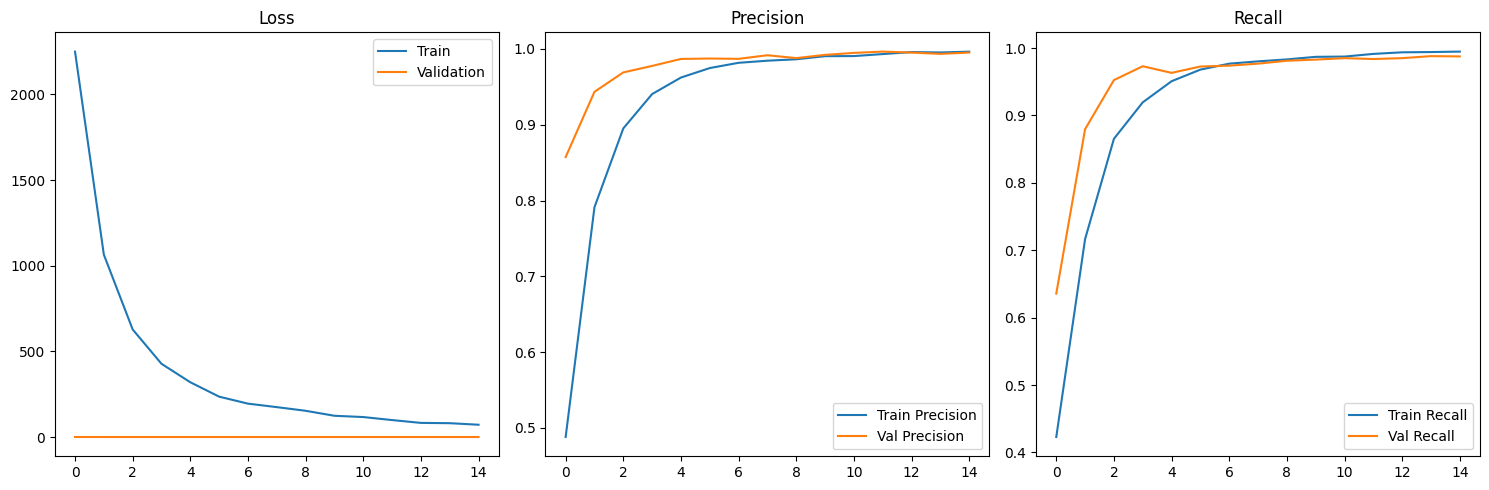

F1-micro: 0.661432777232581


In [ ]:
#multilable text classification for augmented data
import json
import pandas as pd
import re
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import AutoTokenizer, TFAutoModel
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt

# 1. Enhanced Data Loading
def load_and_preprocess(json_path, augment=False):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)

    # Extract techniques and clean text
    df["techniques"] = df["labels"].apply(lambda x: [label["technique"] for label in x])
    df["text"] = df["text"].apply(lambda x: re.sub(r"@\w+|https?://\S+|#[^\s]+", "", x))

    if augment:
        # Add simple augmentation for rare classes
        rare_tech = ['Appeal to authority', 'Obfuscation', 'Repetition']
        aug_samples = []
        for _, row in df[df["techniques"].apply(lambda x: any(t in x for t in rare_tech))].iterrows():
            aug_samples.append({
                "text": re.sub(r"(\w+)\s+", r"\1 \1 ", row["text"]),  # Simple repetition
                "techniques": row["techniques"]
            })
        df = pd.concat([df, pd.DataFrame(aug_samples)])

    return df

# 2. Data Preparation
train_df = load_and_preprocess("/content/drive/MyDrive/Colab Notebooks/dataset/all_aug_for_test.json")
test_df = load_and_preprocess("/content/drive/MyDrive/Colab Notebooks/dataset/task2_test_gold_label_final_mod.json")

all_techniques = sorted(set(tech for sublist in train_df["techniques"] for tech in sublist))
mlb = MultiLabelBinarizer(classes=all_techniques)
mlb.fit(train_df["techniques"])

def prepare_dataset(df):
    labels_matrix = mlb.transform(df["techniques"])
    return pd.DataFrame({
        "text": df["text"],
        **{tech: labels_matrix[:, i] for i, tech in enumerate(mlb.classes_)}
    })

# 3. Advanced Text Cleaning
def clean_arabic_text(text):
    # Normalize Arabic characters more comprehensively
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"[ةه]", "ه", text)
    text = re.sub(r"[ىي]", "ي", text)
    text = re.sub(r"[ؤئ]", "ء", text)

    # Remove diacritics but preserve punctuation
    text = re.sub(r'[\u064B-\u065F]', '', text)  # Remove Arabic diacritics
    text = re.sub(r'[^\u0600-\u06FF\s،؛؟!.،]', '', text)  # Keep Arabic punctuation

    # Handle repeated punctuation
    text = re.sub(r'([!؟.])\1+', r'\1', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

train_processed = prepare_dataset(train_df)
test_processed = prepare_dataset(test_df)

for df in [train_processed, test_processed]:
    df["cleaned_text"] = df["text"].apply(clean_arabic_text)

# 4. Train Val Split
X_train_full, y_train_full = train_processed["cleaned_text"], train_processed[all_techniques]
X_test, y_test = test_processed["cleaned_text"], test_processed[all_techniques]

test_size = 0.2
split_idx = int(len(X_train_full) * (1 - test_size))
X_train, X_val = X_train_full[:split_idx], X_train_full[split_idx:]
y_train, y_val = y_train_full[:split_idx], y_train_full[split_idx:]

# 5. Model Initialization
tokenizer = AutoTokenizer.from_pretrained("CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment")
base_model = TFAutoModel.from_pretrained("CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment")

def tokenize_dataset(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="tf"
    )

train_tokens = tokenize_dataset(X_train)
val_tokens = tokenize_dataset(X_val)
test_tokens = tokenize_dataset(X_test)

# 6. Adaptive Focal Loss with Class Weights

class AdaptiveFocalLoss(tf.keras.losses.Loss):
    def __init__(self, class_frequencies, gamma_base=2.0, alpha=0.25, name='adaptive_focal_loss'):
        super().__init__(name=name)
        self.class_frequencies = class_frequencies
        self.gamma_base = gamma_base
        self.alpha = alpha

        # Convert to tensor with dtype
        self.gamma = {i: tf.constant(gamma_base * (1 + (1 - freq)), dtype=tf.float32)
                     for i, freq in enumerate(class_frequencies)}
        self.alpha_tensor = tf.constant(alpha, dtype=tf.float32)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        gamma_tensor = tf.zeros_like(y_true, dtype=tf.float32)

        for i in range(y_true.shape[1]):
            gamma_tensor = tf.where(
                tf.equal(y_true[:, i:i+1], 1),
                self.gamma[i],
                gamma_tensor
            )

        loss = -self.alpha_tensor * tf.pow(1.0 - pt, gamma_tensor) * tf.math.log(pt + 1e-7)
        return tf.reduce_mean(loss)

    def get_config(self):
        config = super().get_config()
        config.update({
            'class_frequencies': self.class_frequencies.tolist(),  # Convert numpy array to list
            'gamma_base': self.gamma_base,
            'alpha': self.alpha
        })
        return config

    @classmethod
    def from_config(cls, config):
        config['class_frequencies'] = np.array(config['class_frequencies'])  # Convert back to numpy array
        return cls(**config)

class_freq = y_train.mean(axis=0).values.astype(np.float32)
focal_loss = AdaptiveFocalLoss(class_freq)

# 7. Enhanced Model Architecture
from transformers import TFAutoModelForSequenceClassification


def build_enhanced_model():
    input_ids = tf.keras.layers.Input(shape=(None,), dtype=tf.int32, name="input_ids")
    attention_mask = tf.keras.layers.Input(shape=(None,), dtype=tf.int32, name="attention_mask")

    bert_output = base_model(input_ids, attention_mask=attention_mask)

    attention = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=64)(bert_output.last_hidden_state, bert_output.last_hidden_state)
    attention = tf.keras.layers.GlobalAveragePooling1D()(attention)

    dense1 = tf.keras.layers.Dense(256, activation='swish')(attention)
    dense1 = tf.keras.layers.LayerNormalization()(dense1)
    dense1 = tf.keras.layers.Dropout(0.3)(dense1)

    dense2 = tf.keras.layers.Dense(128, activation='swish')(dense1)
    dense2 = tf.keras.layers.LayerNormalization()(dense2)

    output = tf.keras.layers.Dense(len(all_techniques), activation="sigmoid")(dense2)

    return tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)

model = build_enhanced_model()

class HybridLoss(tf.keras.losses.Loss):
    def __init__(self, class_frequencies, gamma=2.0, alpha=0.25, name='hybrid_loss'):
        super().__init__(name=name)
        self.class_frequencies = class_frequencies
        self.gamma = gamma
        self.alpha = alpha
        self.bce = tf.keras.losses.BinaryCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)

    def call(self, y_true, y_pred):
        # Focal loss component
        bce_loss = self.bce(y_true, y_pred)
        pt = tf.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss

        # Dice loss component for imbalanced data
        smooth = 1.0
        intersection = tf.reduce_sum(y_true * y_pred, axis=0)
        union = tf.reduce_sum(y_true + y_pred, axis=0)
        dice_loss = 1.0 - (2.0 * intersection + smooth) / (union + smooth)

        # Combine losses
        total_loss = focal_loss + 0.5 * dice_loss
        return tf.reduce_mean(total_loss)

class CyclicLR(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr=1e-5, max_lr=3e-5, step_size=2000):
        self.initial_lr = initial_lr
        self.max_lr = max_lr
        self.step_size = step_size

    def __call__(self, step):
        cycle = tf.floor(1 + step / (2 * self.step_size))
        x = tf.abs(step / self.step_size - 2 * cycle + 1)
        return self.initial_lr + (self.max_lr - self.initial_lr) * tf.maximum(0.0, 1 - x)


class F1MicroScore(tf.keras.metrics.Metric):
    def __init__(self, name='f1_micro', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision(thresholds=0.5)
        self.recall = tf.keras.metrics.Recall(thresholds=0.5)

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred)
        self.recall.update_state(y_true, y_pred)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + 1e-6))

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-5),
    loss=focal_loss,
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1MicroScore()
    ]
)


class_counts = y_train.sum(axis=0)
total_samples = len(y_train)
class_weights = total_samples / (len(class_counts) * (1 / (class_counts + 1e-6)))
class_weights = {i: float(w) for i, w in enumerate(class_weights)}

# Apply special weights  to existing classes
special_weights = {
    'Obfuscation, Intentional vagueness, Confusion': 3.0,
    'Repetition': 2.5,
    'Appeal to authority': 2.0,
    'Glittering generalities (Virtue)': 2.0
}

for tech, weight in special_weights.items():
    if tech in all_techniques:
        class_weights[all_techniques.index(tech)] = weight

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    patience=15,
    mode="max",
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6
)

# 9. Model Training
history = model.fit(
    {"input_ids": train_tokens["input_ids"], "attention_mask": train_tokens["attention_mask"]},
    y_train,
    validation_data=(
        {"input_ids": val_tokens["input_ids"], "attention_mask": val_tokens["attention_mask"]},
        y_val
    ),
    batch_size=16,
    epochs=15,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights
)


# 10. Advanced Threshold Optimization
def optimize_thresholds(y_true, y_pred_probs):
    thresholds = []
    for i in range(y_pred_probs.shape[1]):
        if y_true[:, i].sum() == 0:
            thresholds.append(0.3)
            continue

        # Coarse search
        best_t, best_f1 = 0.3, 0
        for t in np.linspace(0.1, 0.5, 20):
            f1 = f1_score(y_true[:, i], y_pred_probs[:, i] > t, zero_division=0)
            if f1 > best_f1:
                best_t, best_f1 = t, f1

        # Fine search
        for t in np.linspace(max(0.1, best_t-0.05), min(0.5, best_t+0.05), 50):
            f1 = f1_score(y_true[:, i], y_pred_probs[:, i] > t, zero_division=0)
            if f1 > best_f1:
                best_t, best_f1 = t, f1
        thresholds.append(best_t)

    # Manual adjustments
    adjustments = {
        'Appeal to authority': 0.50,
        'Smears': 0.45,
        'Exaggeration/Minimisation': 0.45,
        'Flag-waving': 0.40,
        'Obfuscation, Intentional vagueness, Confusion': 0.35
    }
    for tech, thresh in adjustments.items():
        thresholds[all_techniques.index(tech)] = thresh

    return thresholds

val_pred_probs = model.predict({"input_ids": val_tokens["input_ids"], "attention_mask": val_tokens["attention_mask"]})
optimal_thresholds = optimize_thresholds(y_val.values, val_pred_probs)


model_save_path = "/content/drive/MyDrive/Colab Notebooks/models/propaganda_detector_new_test"


import os
os.makedirs(model_save_path, exist_ok=True)

# Save the model with the custom loss function
tf.keras.models.save_model(
    model,
    model_save_path,
    save_format='tf',
    include_optimizer=True
)

# save the tokenizer and metadata
tokenizer.save_pretrained(model_save_path)

# Save additional metadata
import joblib
metadata = {
    "mlb": mlb,
    "optimal_thresholds": optimal_thresholds,
    "all_techniques": all_techniques,
    "class_frequencies": class_freq  # Save for recreating the loss
}
joblib.dump(metadata, f"{model_save_path}/metadata.pkl")


# 11. Hybrid Prediction with Rules
def apply_hybrid_rules(texts, pred_probs, thresholds):
    rules = {
        'Appeal to authority': (
            r'(?:خبير|مختص|سلطة|توصية)(?:\s+\S+){0,3}\s+(?:قال|أكد|ذكر|صرح)',
            0.65,
            0.6
        ),
        'Obfuscation, Intentional vagueness, Confusion': (
            r'(?:بعض|عديد|معظم|قطاع)\s+(?:من|منهم|لها)\b|\bربما\b|يحتمل|قد يكون',
            0.55,
            0.4
        ),
        'Repetition': (
            r'(\b\w+\b)(?:\W+\1){2,}',
            0.5,
            0.4
        ),
        'Smears': (
            r'\b(?:فاسد|لص|سارق|نهب|خائن)\b(?:\s+\S+){0,2}\s+(?:اتهام|اتهم|وصف)',
            0.65,
            0.5
        ),
        'Flag-waving': (
            r'(?:وطن|أمة|شرف|انتماء)\s+(?:فخر|تضحيات|دماء|واجب)',
            0.7,
            0.5
        )
    }

    final_preds = np.zeros_like(pred_probs)
    tech_index = {tech:i for i, tech in enumerate(all_techniques)}

    for tech, (pattern, boost, max_thresh) in rules.items():
        i = tech_index[tech]
        compiled = re.compile(pattern)
        tech_thresh = min(thresholds[i] * boost, max_thresh)
        for j, text in enumerate(texts):
            if compiled.search(text):
                final_preds[j,i] = int(pred_probs[j,i] > tech_thresh)
            else:
                final_preds[j,i] = int(pred_probs[j,i] > thresholds[i])

    # Default thresholds for other classes
    for i, tech in enumerate(all_techniques):
        if tech not in rules:
            final_preds[:,i] = (pred_probs[:,i] > thresholds[i]).astype(int)


    for j in range(len(texts)):
        if not final_preds[j].any():
            final_preds[j,np.argmax(pred_probs[j])] = 1

    return final_preds

# Final Evaluation
test_pred_probs = model.predict({"input_ids": test_tokens["input_ids"], "attention_mask": test_tokens["attention_mask"]})
test_preds = apply_hybrid_rules(X_test.tolist(), test_pred_probs, optimal_thresholds)

test_classes_present = [tech for tech in all_techniques if y_test[tech].sum() > 0]
test_class_indices = [all_techniques.index(tech) for tech in test_classes_present]

print("\nOptimized Thresholds:")
for tech, threshold in zip(all_techniques, optimal_thresholds):
    print(f"{tech:>50}: {threshold:.3f}")

print("\nEnhanced Test Performance:")
print(classification_report(
    y_test[test_classes_present],
    test_preds[:, test_class_indices],
    target_names=test_classes_present,
    zero_division=0
))

# Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.title('Precision')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title('Recall')
plt.legend()
plt.tight_layout()
plt.show()
from sklearn.metrics import f1_score


f1_micro = f1_score(y_test, test_preds, average='micro', zero_division=0)
print("F1-micro:", f1_micro)

Some layers from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment were not used when initializing TFBertModel: ['dropout_113', 'classifier']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend m

Epoch 1/15


26/26 [==============================] - 67s 436ms/step - loss: 98.8140 - auc: 0.7318 - precision: 0.2280 - recall: 0.3952 - f1_micro: 0.2892 - val_loss: 0.0194 - val_auc: 0.8166 - val_precision: 0.5455 - val_recall: 0.1548 - val_f1_micro: 0.2412 - lr: 2.0000e-05
Epoch 2/15
26/26 [==============================] - 8s 305ms/step - loss: 52.5132 - auc: 0.8539 - precision: 0.5012 - recall: 0.3222 - f1_micro: 0.3923 - val_loss: 0.0180 - val_auc: 0.8467 - val_precision: 0.5684 - val_recall: 0.3484 - val_f1_micro: 0.4320 - lr: 2.0000e-05
Epoch 3/15
26/26 [==============================] - 6s 245ms/step - loss: 47.5672 - auc: 0.8807 - precision: 0.5697 - recall: 0.3698 - f1_micro: 0.4485 - val_loss: 0.0165 - val_auc: 0.8646 - val_precision: 0.6702 - val_recall: 0.4065 - val_f1_micro: 0.5060 - lr: 2.0000e-05
Epoch 4/15
26/26 [==============================] - 6s 231ms/step - loss: 43.9302 - auc: 0.9053 - precision: 0.6034 - recall: 0.3937 - f1_micro: 0.4765 - val_loss: 0.0181 - val_auc: 0.8350

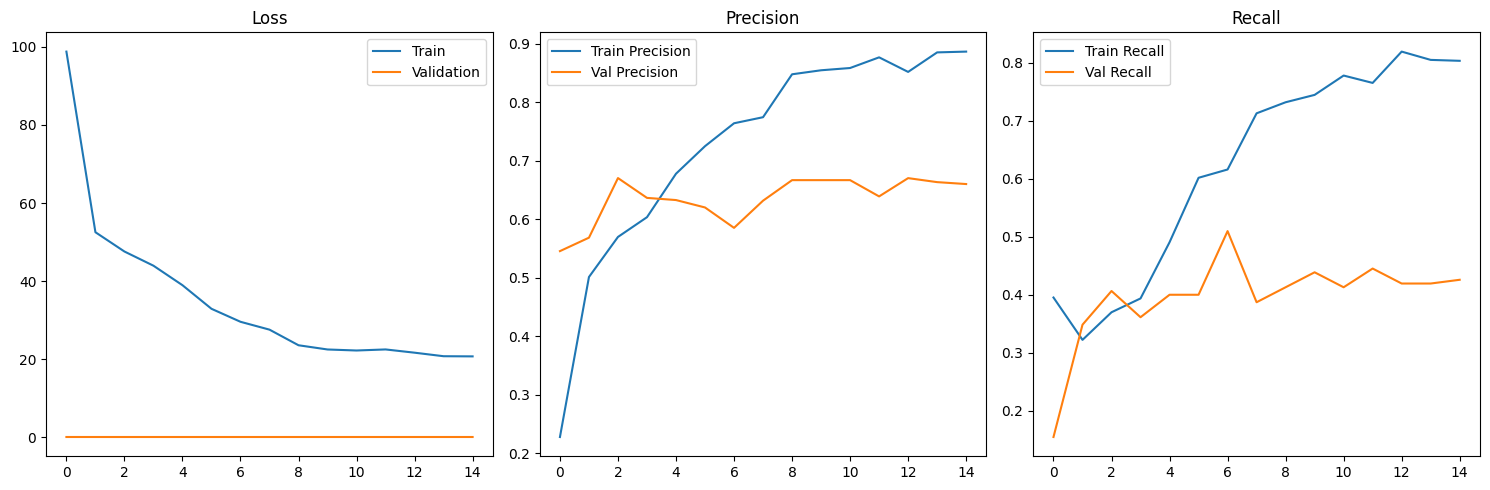

F1-micro: 0.5737855178735105


In [ ]:
#multilable text classification for original data
import json
import pandas as pd
import re
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import AutoTokenizer, TFAutoModel
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt

# 1. Data Loading
def load_and_preprocess(json_path, augment=False):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)

    # Extract techniques and clean text
    df["techniques"] = df["labels"].apply(lambda x: [label["technique"] for label in x])
    df["text"] = df["text"].apply(lambda x: re.sub(r"@\w+|https?://\S+|#[^\s]+", "", x))

    if augment:
        # Add simple augmentation for rare classes
        rare_tech = ['Appeal to authority', 'Obfuscation', 'Repetition']
        aug_samples = []
        for _, row in df[df["techniques"].apply(lambda x: any(t in x for t in rare_tech))].iterrows():
            aug_samples.append({
                "text": re.sub(r"(\w+)\s+", r"\1 \1 ", row["text"]),  # Simple repetition
                "techniques": row["techniques"]
            })
        df = pd.concat([df, pd.DataFrame(aug_samples)])

    return df

# 2. Data Preparation
train_df = load_and_preprocess("/content/drive/MyDrive/Colab Notebooks/dataset/task2_train.json")
test_df = load_and_preprocess("/content/drive/MyDrive/Colab Notebooks/dataset/task2_test_gold_label_final_mod.json")

all_techniques = sorted(set(tech for sublist in train_df["techniques"] for tech in sublist))

mlb = MultiLabelBinarizer(classes=all_techniques)
mlb.fit(train_df["techniques"])

def prepare_dataset(df):
    labels_matrix = mlb.transform(df["techniques"])
    return pd.DataFrame({
        "text": df["text"],
        **{tech: labels_matrix[:, i] for i, tech in enumerate(mlb.classes_)}
    })

# 3. Advanced Text Cleaning
def clean_arabic_text(text):
    # Normalize Arabic characters more comprehensively
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"[ةه]", "ه", text)
    text = re.sub(r"[ىي]", "ي", text)
    text = re.sub(r"[ؤئ]", "ء", text)


    text = re.sub(r'[\u064B-\u065F]', '', text)  # Remove Arabic diacritics
    text = re.sub(r'[^\u0600-\u06FF\s،؛؟!.،]', '', text)  # Keep Arabic punctuation

    # Handle repeated punctuation
    text = re.sub(r'([!؟.])\1+', r'\1', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

train_processed = prepare_dataset(train_df)
test_processed = prepare_dataset(test_df)

for df in [train_processed, test_processed]:
    df["cleaned_text"] = df["text"].apply(clean_arabic_text)

# 4. Train and Val Split
X_train_full, y_train_full = train_processed["cleaned_text"], train_processed[all_techniques]
X_test, y_test = test_processed["cleaned_text"], test_processed[all_techniques]

test_size = 0.2
split_idx = int(len(X_train_full) * (1 - test_size))
X_train, X_val = X_train_full[:split_idx], X_train_full[split_idx:]
y_train, y_val = y_train_full[:split_idx], y_train_full[split_idx:]

# 5. Model Initialization
tokenizer = AutoTokenizer.from_pretrained("CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment")
base_model = TFAutoModel.from_pretrained("CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment")

def tokenize_dataset(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="tf"
    )

train_tokens = tokenize_dataset(X_train)
val_tokens = tokenize_dataset(X_val)
test_tokens = tokenize_dataset(X_test)

# 6. Adaptive Focal Loss with Class Weights

class AdaptiveFocalLoss(tf.keras.losses.Loss):
    def __init__(self, class_frequencies, gamma_base=2.0, alpha=0.25, name='adaptive_focal_loss'):
        super().__init__(name=name)
        self.class_frequencies = class_frequencies
        self.gamma_base = gamma_base
        self.alpha = alpha


        self.gamma = {i: tf.constant(gamma_base * (1 + (1 - freq)), dtype=tf.float32)
                     for i, freq in enumerate(class_frequencies)}
        self.alpha_tensor = tf.constant(alpha, dtype=tf.float32)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        gamma_tensor = tf.zeros_like(y_true, dtype=tf.float32)

        for i in range(y_true.shape[1]):
            gamma_tensor = tf.where(
                tf.equal(y_true[:, i:i+1], 1),
                self.gamma[i],
                gamma_tensor
            )

        loss = -self.alpha_tensor * tf.pow(1.0 - pt, gamma_tensor) * tf.math.log(pt + 1e-7)
        return tf.reduce_mean(loss)

    def get_config(self):
        config = super().get_config()
        config.update({
            'class_frequencies': self.class_frequencies.tolist(),  # Convert numpy array to list
            'gamma_base': self.gamma_base,
            'alpha': self.alpha
        })
        return config

    @classmethod
    def from_config(cls, config):
        config['class_frequencies'] = np.array(config['class_frequencies'])  # Convert back to numpy array
        return cls(**config)

class_freq = y_train.mean(axis=0).values.astype(np.float32)
focal_loss = AdaptiveFocalLoss(class_freq)

# 7. Enhanced Model Architecture
from transformers import TFAutoModelForSequenceClassification


def build_enhanced_model():
    input_ids = tf.keras.layers.Input(shape=(None,), dtype=tf.int32, name="input_ids")
    attention_mask = tf.keras.layers.Input(shape=(None,), dtype=tf.int32, name="attention_mask")


    bert_output = base_model(input_ids, attention_mask=attention_mask)


    attention = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=64)(bert_output.last_hidden_state, bert_output.last_hidden_state)
    attention = tf.keras.layers.GlobalAveragePooling1D()(attention)


    dense1 = tf.keras.layers.Dense(256, activation='swish')(attention)
    dense1 = tf.keras.layers.LayerNormalization()(dense1)
    dense1 = tf.keras.layers.Dropout(0.3)(dense1)

    dense2 = tf.keras.layers.Dense(128, activation='swish')(dense1)
    dense2 = tf.keras.layers.LayerNormalization()(dense2)


    output = tf.keras.layers.Dense(len(all_techniques), activation="sigmoid")(dense2)

    return tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)

model = build_enhanced_model()

class HybridLoss(tf.keras.losses.Loss):
    def __init__(self, class_frequencies, gamma=2.0, alpha=0.25, name='hybrid_loss'):
        super().__init__(name=name)
        self.class_frequencies = class_frequencies
        self.gamma = gamma
        self.alpha = alpha
        self.bce = tf.keras.losses.BinaryCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)

    def call(self, y_true, y_pred):
        # Focal loss component
        bce_loss = self.bce(y_true, y_pred)
        pt = tf.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss

        # Dice loss component for imbalanced data
        smooth = 1.0
        intersection = tf.reduce_sum(y_true * y_pred, axis=0)
        union = tf.reduce_sum(y_true + y_pred, axis=0)
        dice_loss = 1.0 - (2.0 * intersection + smooth) / (union + smooth)

        # Combine losses
        total_loss = focal_loss + 0.5 * dice_loss
        return tf.reduce_mean(total_loss)


# Custom learning rate scheduler
class CyclicLR(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr=1e-5, max_lr=3e-5, step_size=2000):
        self.initial_lr = initial_lr
        self.max_lr = max_lr
        self.step_size = step_size

    def __call__(self, step):
        cycle = tf.floor(1 + step / (2 * self.step_size))
        x = tf.abs(step / self.step_size - 2 * cycle + 1)
        return self.initial_lr + (self.max_lr - self.initial_lr) * tf.maximum(0.0, 1 - x)


class F1MicroScore(tf.keras.metrics.Metric):
    def __init__(self, name='f1_micro', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision(thresholds=0.5)
        self.recall = tf.keras.metrics.Recall(thresholds=0.5)

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred)
        self.recall.update_state(y_true, y_pred)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + 1e-6))

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()


model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-5),
    loss=focal_loss,
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1MicroScore()
    ]
)


class_counts = y_train.sum(axis=0)
total_samples = len(y_train)
class_weights = total_samples / (len(class_counts) * (1 / (class_counts + 1e-6)))  # Added missing parenthesis
class_weights = {i: float(w) for i, w in enumerate(class_weights)}

# Apply special weights to existing classes
special_weights = {
    'Obfuscation, Intentional vagueness, Confusion': 3.0,
    'Repetition': 2.5,
    'Appeal to authority': 2.0,
    'Glittering generalities (Virtue)': 2.0
}

for tech, weight in special_weights.items():
    if tech in all_techniques:
        class_weights[all_techniques.index(tech)] = weight

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    patience=15,
    mode="max",
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6
)

# 9. Model Training
history = model.fit(
    {"input_ids": train_tokens["input_ids"], "attention_mask": train_tokens["attention_mask"]},
    y_train,
    validation_data=(
        {"input_ids": val_tokens["input_ids"], "attention_mask": val_tokens["attention_mask"]},
        y_val
    ),
    batch_size=16,
    epochs=15,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights
)


# 10. Advanced Threshold Optimization
def optimize_thresholds(y_true, y_pred_probs):
    thresholds = []
    for i in range(y_pred_probs.shape[1]):
        if y_true[:, i].sum() == 0:
            thresholds.append(0.3)
            continue

        # Coarse search
        best_t, best_f1 = 0.3, 0
        for t in np.linspace(0.1, 0.5, 20):
            f1 = f1_score(y_true[:, i], y_pred_probs[:, i] > t, zero_division=0)
            if f1 > best_f1:
                best_t, best_f1 = t, f1

        # Fine search
        for t in np.linspace(max(0.1, best_t-0.05), min(0.5, best_t+0.05), 50):
            f1 = f1_score(y_true[:, i], y_pred_probs[:, i] > t, zero_division=0)
            if f1 > best_f1:
                best_t, best_f1 = t, f1
        thresholds.append(best_t)

    # Manual adjustments
    adjustments = {
        'Appeal to authority': 0.50,
        'Smears': 0.45,
        'Exaggeration/Minimisation': 0.45,
        'Flag-waving': 0.40,
        'Obfuscation, Intentional vagueness, Confusion': 0.35
    }
    for tech, thresh in adjustments.items():
        thresholds[all_techniques.index(tech)] = thresh

    return thresholds

val_pred_probs = model.predict({"input_ids": val_tokens["input_ids"], "attention_mask": val_tokens["attention_mask"]})
optimal_thresholds = optimize_thresholds(y_val.values, val_pred_probs)


model_save_path = "/content/drive/MyDrive/Colab Notebooks/models/propaganda_detector_bert_original"


import os
os.makedirs(model_save_path, exist_ok=True)

# Save the model with the custom loss function
tf.keras.models.save_model(
    model,
    model_save_path,
    save_format='tf',
    include_optimizer=True
)

# save the tokenizer and metadata
tokenizer.save_pretrained(model_save_path)

# Save additional metadata
import joblib
metadata = {
    "mlb": mlb,
    "optimal_thresholds": optimal_thresholds,
    "all_techniques": all_techniques,
    "class_frequencies": class_freq
}
joblib.dump(metadata, f"{model_save_path}/metadata.pkl")


# 11. Hybrid Prediction with Rules
def apply_hybrid_rules(texts, pred_probs, thresholds):
    rules = {
        'Appeal to authority': (
            r'(?:خبير|مختص|سلطة|توصية)(?:\s+\S+){0,3}\s+(?:قال|أكد|ذكر|صرح)',
            0.65,
            0.6
        ),
        'Obfuscation, Intentional vagueness, Confusion': (
            r'(?:بعض|عديد|معظم|قطاع)\s+(?:من|منهم|لها)\b|\bربما\b|يحتمل|قد يكون',
            0.55,
            0.4
        ),
        'Repetition': (
            r'(\b\w+\b)(?:\W+\1){2,}',
            0.5,
            0.4
        ),
        'Smears': (
            r'\b(?:فاسد|لص|سارق|نهب|خائن)\b(?:\s+\S+){0,2}\s+(?:اتهام|اتهم|وصف)',
            0.65,
            0.5
        ),
        'Flag-waving': (
            r'(?:وطن|أمة|شرف|انتماء)\s+(?:فخر|تضحيات|دماء|واجب)',
            0.7,
            0.5
        )
    }

    final_preds = np.zeros_like(pred_probs)
    tech_index = {tech:i for i, tech in enumerate(all_techniques)}

    for tech, (pattern, boost, max_thresh) in rules.items():
        i = tech_index[tech]
        compiled = re.compile(pattern)
        tech_thresh = min(thresholds[i] * boost, max_thresh)
        for j, text in enumerate(texts):
            if compiled.search(text):
                final_preds[j,i] = int(pred_probs[j,i] > tech_thresh)
            else:
                final_preds[j,i] = int(pred_probs[j,i] > thresholds[i])

    # Default thresholds for other classes
    for i, tech in enumerate(all_techniques):
        if tech not in rules:
            final_preds[:,i] = (pred_probs[:,i] > thresholds[i]).astype(int)


    for j in range(len(texts)):
        if not final_preds[j].any():
            final_preds[j,np.argmax(pred_probs[j])] = 1

    return final_preds

# Final Evaluation
test_pred_probs = model.predict({"input_ids": test_tokens["input_ids"], "attention_mask": test_tokens["attention_mask"]})
test_preds = apply_hybrid_rules(X_test.tolist(), test_pred_probs, optimal_thresholds)

test_classes_present = [tech for tech in all_techniques if y_test[tech].sum() > 0]
test_class_indices = [all_techniques.index(tech) for tech in test_classes_present]

print("\nOptimized Thresholds:")
for tech, threshold in zip(all_techniques, optimal_thresholds):
    print(f"{tech:>50}: {threshold:.3f}")

print("\nEnhanced Test Performance:")
print(classification_report(
    y_test[test_classes_present],
    test_preds[:, test_class_indices],
    target_names=test_classes_present,
    zero_division=0
))

# Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.title('Precision')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title('Recall')
plt.legend()
plt.tight_layout()
plt.show()
from sklearn.metrics import f1_score


f1_micro = f1_score(y_test, test_preds, average='micro', zero_division=0)
print("F1-micro:", f1_micro)